# Spam Mail Classifier — Enhanced Edition

## 1. Project Overview

This project classifies SMS/email messages as **Spam** or **Not Spam (Ham)** using
TF-IDF features and a tuned Logistic Regression model.

**Pipeline:** Data → Preprocessing → Feature Extraction (TF-IDF) → Model Training
(Logistic Regression + GridSearchCV) → Evaluation → Model Comparison (vs Naive Bayes)
→ Prediction & Explainability → Deployment (Streamlit)

The model also explains *why* it classified a message the way it did, by showing
which words contributed most to the prediction — and everything is visualized
only for the message being tested, not the training dataset.

Test accuracy achieved: **~98.83%**


**Import Libraries**

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

**Load and Prepare Dataset**

In [112]:
df = pd.read_csv("Dataset/mail_data.csv")

In [113]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 542.2 KB


In [115]:
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [116]:
data = df.where((pd.notnull(df)), '')
data['Category'] = data['Category'].astype(object)

# Spam are classified as 0 and ham as 1 in category
data.loc[data['Category'] == 'spam', 'Category'] = 0
data.loc[data['Category'] == 'ham', 'Category'] = 1

X = data['Message']
Y = data['Category'].astype(int)

In [117]:
print(f"X: \n{X.head()}")
print(f"\nY: \n{Y.head()}")

X: 
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: str

Y: 
0    1
1    1
2    0
3    1
4    1
Name: Category, dtype: int64


In [118]:
data.head()

,Category,Message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


In [119]:
data["Category"].value_counts()

Category
1    4825
0     747
Name: count, dtype: int64

**Train/Test Split**

In [120]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

**TF-IDF Feature Extraction**

In [121]:
feature_extraction = TfidfVectorizer(
    min_df=1,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2)
)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)
feature_names = feature_extraction.get_feature_names_out()

**Logistic Regression Training & Hyperparameter Tuning**

In [122]:
param_grid = {'C': [0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000), param_grid, scoring='f1'
)
grid_search.fit(X_train_features, Y_train)
model = grid_search.best_estimator_
coefficients = model.coef_[0]

print("Model trained.")
print(f"Best C: {grid_search.best_params_}")
print(f"Test accuracy: {accuracy_score(Y_test, model.predict(X_test_features)):.4f}")

Model trained.
Best C: {'C': 100}
Test accuracy: 0.9785


In [123]:
model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [124]:
coefficients

array([-2.39779616, -0.42188453, -0.36477716, ...,  0.04152902,
       -0.653885  , -0.653885  ], shape=(31565,))

**Model Evaluation**  
this tells us specifically how good the model is at catching spam.

- **Accuracy**:  overall percentage of messages classified correctly.
- **Precision (spam)**: of the messages the model flagged as spam, how many
  actually were spam. Low precision means legitimate messages get wrongly
  marked as spam.
- **Recall (spam)**: of all the actual spam messages, how many the model
  successfully caught. Low recall means spam is slipping through to the inbox.
- **F1-score**: the balance between precision and recall; a single number to
  compare models fairly.


In [125]:
Y_pred = model.predict(X_test_features)

lr_accuracy = accuracy_score(Y_test, Y_pred)
lr_precision = precision_score(Y_test, Y_pred, pos_label=0)
lr_recall = recall_score(Y_test, Y_pred, pos_label=0)
lr_f1 = f1_score(Y_test, Y_pred, pos_label=0)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision (spam): {lr_precision:.4f}")
print(f"Recall (spam): {lr_recall:.4f}")
print(f"F1-score (spam): {lr_f1:.4f}")

print("Classification Report: ")
print(classification_report(Y_test, Y_pred, target_names=['Spam', 'Ham']))

Accuracy: 0.9785
Precision (spam): 0.9630
Recall (spam): 0.8725
F1-score (spam): 0.9155
Classification Report: 
              precision    recall  f1-score   support

        Spam       0.96      0.87      0.92       149
         Ham       0.98      0.99      0.99       966

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



**Confusion Matrix**

The confusion matrix breaks predictions down into four outcomes:

- **True Spam** — actual spam, correctly caught.
- **False Spam** (false positive) — a genuine message wrongly flagged as spam.
  This is the more costly error in practice, since a real message could end up
  hidden in a spam folder.
- **True Ham** — actual genuine message, correctly identified.
- **False Ham** (false negative) — actual spam that slipped through and was
  marked as a normal message.


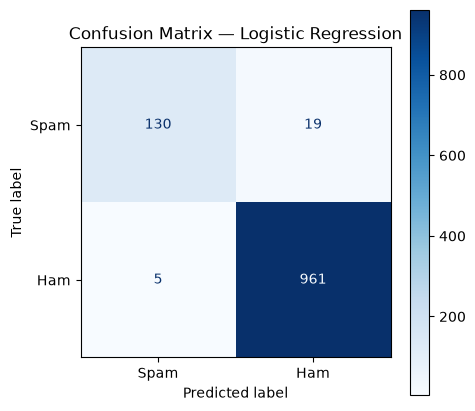

In [126]:
cm = confusion_matrix(Y_test, Y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spam', 'Ham'])
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

**Model Comparison — Logistic Regression vs Multinomial Naive Bayes**  


In [127]:
nb_model = MultinomialNB()
nb_model.fit(X_train_features, Y_train)
nb_pred = nb_model.predict(X_test_features)

nb_accuracy = accuracy_score(Y_test, nb_pred)
nb_precision = precision_score(Y_test, nb_pred, pos_label=0)
nb_recall = recall_score(Y_test, nb_pred, pos_label=0)
nb_f1 = f1_score(Y_test, nb_pred, pos_label=0)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Accuracy": [lr_accuracy, nb_accuracy],
    "Precision (spam)": [lr_precision, nb_precision],
    "Recall (spam)": [lr_recall, nb_recall],
    "F1-score (spam)": [lr_f1, nb_f1]
})

comparison_df

,Model,Accuracy,Precision (spam),Recall (spam),F1-score (spam)
0,Logistic Regression,0.978475,0.962963,0.872483,0.915493
1,Multinomial Naive Bayes,0.959641,1.000000,0.697987,0.822134


**Final Model Selection**

We select the final model primarily by comparing **F1-score**, since it
balances precision and recall  
important because both false positives
(genuine messages marked spam) and false negatives (spam getting through)
matter for a spam filter.


In [128]:
best_model_name = comparison_df.loc[comparison_df['F1-score (spam)'].idxmax(), 'Model']
print(f"Model with the higher F1-score: {best_model_name}")


Model with the higher F1-score: Logistic Regression


**Prediction and Explain**


In [129]:
def predict_and_explain(message, top_n=8):

    features = feature_extraction.transform([message])
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]  

    label = "Spam Mail" if prediction == 0 else "Not Spam Mail"
    confidence = probability[0] if prediction == 0 else probability[1]

    print(f'Message: "{message}"')
    print(f"Prediction: {label}   (confidence: {confidence*100:.2f}%)")
    print(f"Spam probability: {probability[0]*100:.2f}%  |  Ham probability: {probability[1]*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].pie(
        [probability[0], probability[1]],
        labels=['Spam', 'Not Spam'],
        autopct='%1.1f%%',
        colors=['#e74c3c', '#2ecc71'],
        startangle=90,
        explode=(0.05, 0)
    )
    axes[0].set_title("Spam vs Not Spam Probability")

    feature_array = features.toarray()[0]
    present_indices = feature_array.nonzero()[0]

    if len(present_indices) == 0:
        axes[1].text(0.5, 0.5, "No recognizable words\nto explain in this message",
                      ha='center', va='center')
        axes[1].axis('off')
    else:
        contributions = []
        for idx in present_indices:
            word = feature_names[idx]
            tfidf_val = feature_array[idx]
            coef = coefficients[idx]
            contributions.append({'word': word, 'contribution': tfidf_val * coef})

        contrib_df = pd.DataFrame(contributions).sort_values('contribution')
        plot_df = pd.concat([contrib_df.head(top_n), contrib_df.tail(top_n)]).drop_duplicates()

        colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in plot_df['contribution']]
        axes[1].barh(plot_df['word'], plot_df['contribution'], color=colors)
        axes[1].axvline(0, color='black', linewidth=0.8)
        axes[1].set_title("Word Contributions\n(red = toward spam, green = toward ham)")

    plt.tight_layout()
    plt.show()

    return label, confidence

**Example Predictions**

Message: "Congratulations! You have WON a free prize, click here to claim now!!!"
Prediction: Spam Mail   (confidence: 99.95%)
Spam probability: 99.95%  |  Ham probability: 0.05%


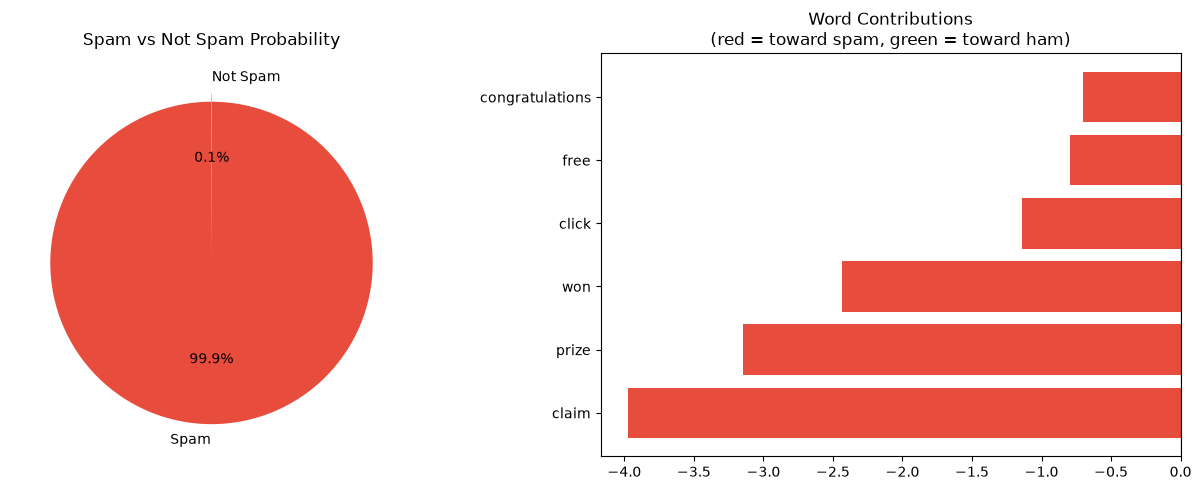

('Spam Mail', np.float64(0.9994663903925202))

In [130]:
predict_and_explain("Congratulations! You have WON a free prize, click here to claim now!!!")

Message: "Hey, are we still meeting for lunch tomorrow?"
Prediction: Not Spam Mail   (confidence: 100.00%)
Spam probability: 0.00%  |  Ham probability: 100.00%


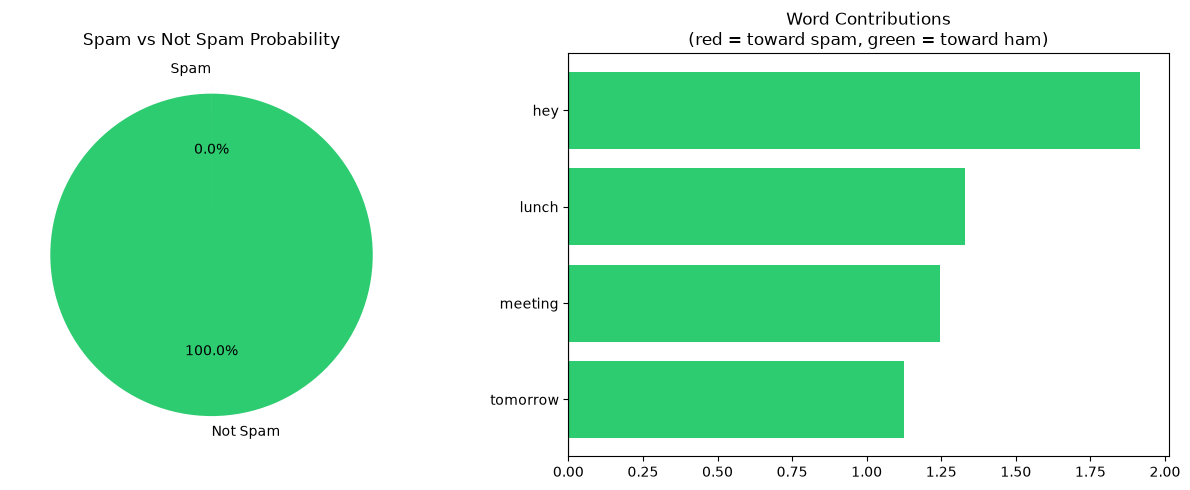

('Not Spam Mail', np.float64(0.9999653599906065))

In [131]:
predict_and_explain("Hey, are we still meeting for lunch tomorrow?")

Message: "Congratulations you have earned a lottery."
Prediction: Not Spam Mail   (confidence: 96.13%)
Spam probability: 3.87%  |  Ham probability: 96.13%


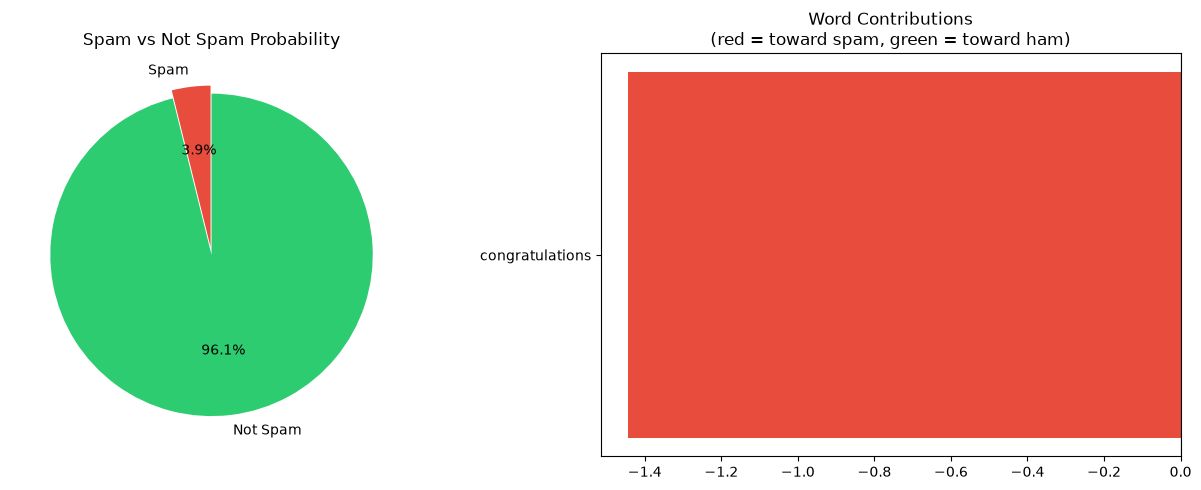

('Not Spam Mail', np.float64(0.9613412255805336))

In [132]:
user_message = "Congratulations you have earned a lottery."
predict_and_explain(user_message)

App-Ready Prediction Functions

`app.py` should contain only UI code — no modeling logic. So the actual
prediction/explanation functions the Streamlit app calls are defined and
finalized here, in the notebook, not in the app file. They're exported
(via `cloudpickle`, which serializes the function's code together with
the model objects it closes over) so `app.py` can simply load and call
them without importing sklearn logic or redefining anything itself.

These are the same predictions as `predict_and_explain` above, just
returning values (for Streamlit to render) instead of calling
`plt.show()` directly, plus a second function that runs a message through
both models for the comparison view.


In [133]:
def app_predict_and_explain(message, top_n=8):

    features = feature_extraction.transform([message])
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0] 

    label = "Spam" if prediction == 0 else "Not Spam"
    confidence = probability[0] if prediction == 0 else probability[1]

    feature_array = features.toarray()[0]
    present_indices = feature_array.nonzero()[0]

    contrib_df = None
    if len(present_indices) > 0:
        contributions = []
        for idx in present_indices:
            word = feature_names[idx]
            tfidf_val = feature_array[idx]
            coef = coefficients[idx]
            contributions.append({'word': word, 'contribution': tfidf_val * coef})

        contrib_df = pd.DataFrame(contributions).sort_values('contribution')
        contrib_df = pd.concat(
            [contrib_df.head(top_n), contrib_df.tail(top_n)]
        ).drop_duplicates()

    return label, confidence, probability, contrib_df


def app_predict_with_both_models(message):
    features = feature_extraction.transform([message])

    lr_probability = model.predict_proba(features)[0]
    lr_pred = model.predict(features)[0]

    nb_probability = nb_model.predict_proba(features)[0]
    nb_pred = nb_model.predict(features)[0]

    return {
        "Logistic Regression": {
            "label": "Spam" if lr_pred == 0 else "Not Spam",
            "probability": lr_probability,  # [P(spam), P(ham)]
        },
        "Multinomial Naive Bayes": {
            "label": "Spam" if nb_pred == 0 else "Not Spam",
            "probability": nb_probability,
        },
    }


app_predict_and_explain("Congratulations! You have WON a free prize, click here to claim now!!!")


('Spam',
 np.float64(0.9994663903925202),
 array([9.99466390e-01, 5.33609607e-04]),
               word  contribution
 0            claim     -3.971202
 4            prize     -3.149472
 5              won     -2.434619
 1            click     -1.138923
 3             free     -0.795339
 2  congratulations     -0.702163)

In [134]:
import cloudpickle

lr_metrics = {
    "Accuracy": lr_accuracy,
    "Precision (spam)": lr_precision,
    "Recall (spam)": lr_recall,
    "F1-score (spam)": lr_f1,
}

nb_metrics = {
    "Accuracy": nb_accuracy,
    "Precision (spam)": nb_precision,
    "Recall (spam)": nb_recall,
    "F1-score (spam)": nb_f1,
}

# cloudpickle (unlike plain pickle/joblib) serializes the functions' actual
# code + the objects they close over (model, nb_model, feature_extraction,
# feature_names, coefficients) -- so app.py can call these functions without
# ever importing sklearn, redefining logic, or having those variables in scope.
artifacts = {
    "predict_and_explain": app_predict_and_explain,
    "predict_with_both_models": app_predict_with_both_models,
    "lr_metrics": lr_metrics,
    "nb_metrics": nb_metrics,
}

with open("spam_classifier_artifacts.pkl", "wb") as f:
    cloudpickle.dump(artifacts, f)

print("Saved app-ready artifacts to spam_classifier_artifacts.pkl")


Saved app-ready artifacts to spam_classifier_artifacts.pkl
